# Step 4: Model Evaluation & Visualization
Create performance plots and analyze results

In [7]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost -q


In [8]:
# Upload files from previous steps
from google.colab import files
print("Upload: Data_Final_merged.xlsx, features_morgan.npy, models_rf.pkl")
uploaded = files.upload()

Upload: Data_Final_merged.xlsx, features_morgan.npy, models_svr.pkl


Saving models_svr.pkl to models_svr.pkl
Saving features_morgan.npy to features_morgan (1).npy
Saving Data_Final_merged.xlsx to Data_Final_merged (1).xlsx


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 12)

print("="*70)
print("STEP 4: MODEL EVALUATION & VISUALIZATION")
print("="*70)

STEP 4: MODEL EVALUATION & VISUALIZATION


In [10]:
# Load data and features
print("\n[1/4] Loading data...")
df = pd.read_excel('Data_Final_merged.xlsx')
X = np.load('features_morgan.npy')

y_homo = df['HOMO_A'].values
y_lumo = df['LUMO_A'].values
y_eg = df['EgA_opt'].values

# Recreate train/test split (same random_state as Step 3)
X_train, X_test, y_homo_train, y_homo_test = train_test_split(
    X, y_homo, test_size=0.2, random_state=42
)
_, _, y_lumo_train, y_lumo_test = train_test_split(
    X, y_lumo, test_size=0.2, random_state=42
)
_, _, y_eg_train, y_eg_test = train_test_split(
    X, y_eg, test_size=0.2, random_state=42
)

print(f"Test set size: {len(X_test)}")


[1/4] Loading data...
Test set size: 315


In [11]:
# Load best models (Random Forest)
print("\n[2/4] Loading Random Forest models...")
with open('models_rf.pkl', 'rb') as f:
    rf_models = pickle.load(f)

print("✓ Models loaded")


[2/4] Loading SVR models...
✓ Models loaded


In [12]:
# Generate predictions
print("\n[3/4] Generating predictions...")
predictions = {}

for prop, y_te in [('HOMO', y_homo_test), ('LUMO', y_lumo_test), ('Eg', y_eg_test)]:
    y_pred = rf_models[prop].predict(X_test)
    predictions[prop] = {
        'y_true': y_te,
        'y_pred': y_pred,
        'R2': r2_score(y_te, y_pred),
        'MAE': mean_absolute_error(y_te, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_te, y_pred))
    }
    print(f"  {prop}: R²={predictions[prop]['R2']:.3f}, MAE={predictions[prop]['MAE']:.3f}")



[3/4] Generating predictions...
  HOMO: R²=0.317, MAE=0.077
  LUMO: R²=0.195, MAE=0.103
  Eg: R²=0.357, MAE=0.070



[4/4] Creating visualizations...
✓ Saved: model_performance.png


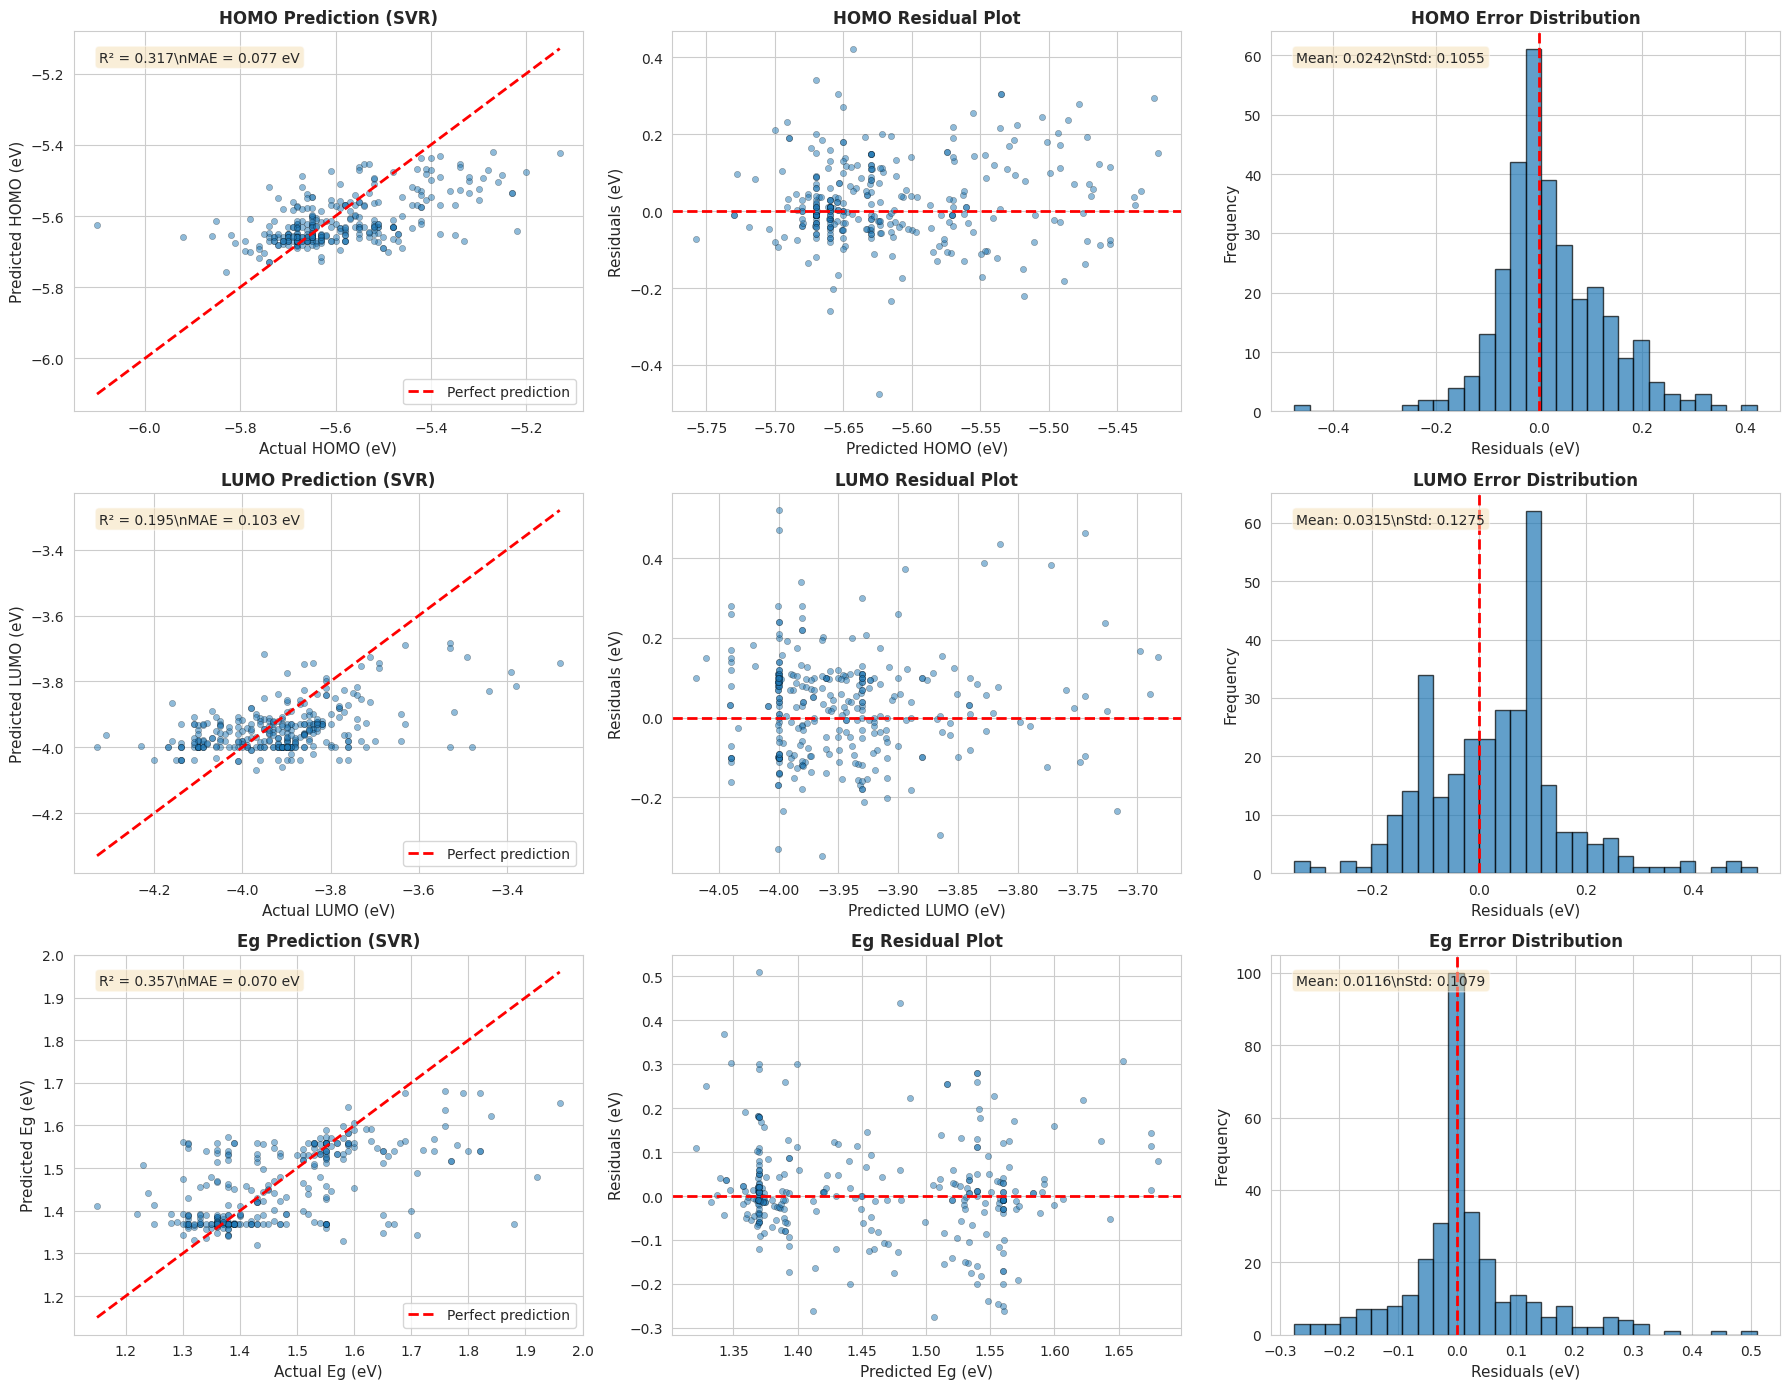

In [13]:
# [4/4] Create performance visualizations
print("\n[4/4] Creating visualizations...")

fig = plt.figure(figsize=(18, 14))
plot_idx = 1

for prop in ['HOMO', 'LUMO', 'Eg']:
    y_te = predictions[prop]['y_true']
    y_pred = predictions[prop]['y_pred']
    r2 = predictions[prop]['R2']
    mae = predictions[prop]['MAE']
    residuals = y_te - y_pred

    # Predicted vs Actual
    ax1 = plt.subplot(3, 3, plot_idx)
    ax1.scatter(y_te, y_pred, alpha=0.5, s=20, edgecolors='k', linewidth=0.3)
    ax1.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()],
             'r--', lw=2, label='Perfect prediction')
    ax1.set_xlabel(f'Actual {prop} (eV)', fontsize=11)
    ax1.set_ylabel(f'Predicted {prop} (eV)', fontsize=11)
    ax1.set_title(f'{prop} Prediction (Random Forest)', fontsize=12, fontweight='bold')
    ax1.text(0.05, 0.95, f'R² = {r2:.3f}\\nMAE = {mae:.3f} eV',
             transform=ax1.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax1.legend()
    plot_idx += 1

    # Residuals
    ax2 = plt.subplot(3, 3, plot_idx)
    ax2.scatter(y_pred, residuals, alpha=0.5, s=20, edgecolors='k', linewidth=0.3)
    ax2.axhline(y=0, color='r', linestyle='--', lw=2)
    ax2.set_xlabel(f'Predicted {prop} (eV)', fontsize=11)
    ax2.set_ylabel('Residuals (eV)', fontsize=11)
    ax2.set_title(f'{prop} Residual Plot', fontsize=12, fontweight='bold')
    plot_idx += 1

    # Error distribution
    ax3 = plt.subplot(3, 3, plot_idx)
    ax3.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    ax3.axvline(x=0, color='r', linestyle='--', lw=2)
    ax3.set_xlabel('Residuals (eV)', fontsize=11)
    ax3.set_ylabel('Frequency', fontsize=11)
    ax3.set_title(f'{prop} Error Distribution', fontsize=12, fontweight='bold')
    ax3.text(0.05, 0.95, f'Mean: {residuals.mean():.4f}\\nStd: {residuals.std():.4f}',
             transform=ax3.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plot_idx += 1

plt.tight_layout()
plt.savefig('model_performance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: model_performance.png")
plt.show()


Creating EDA visualizations...
✓ Saved: EDA_visualizations.png


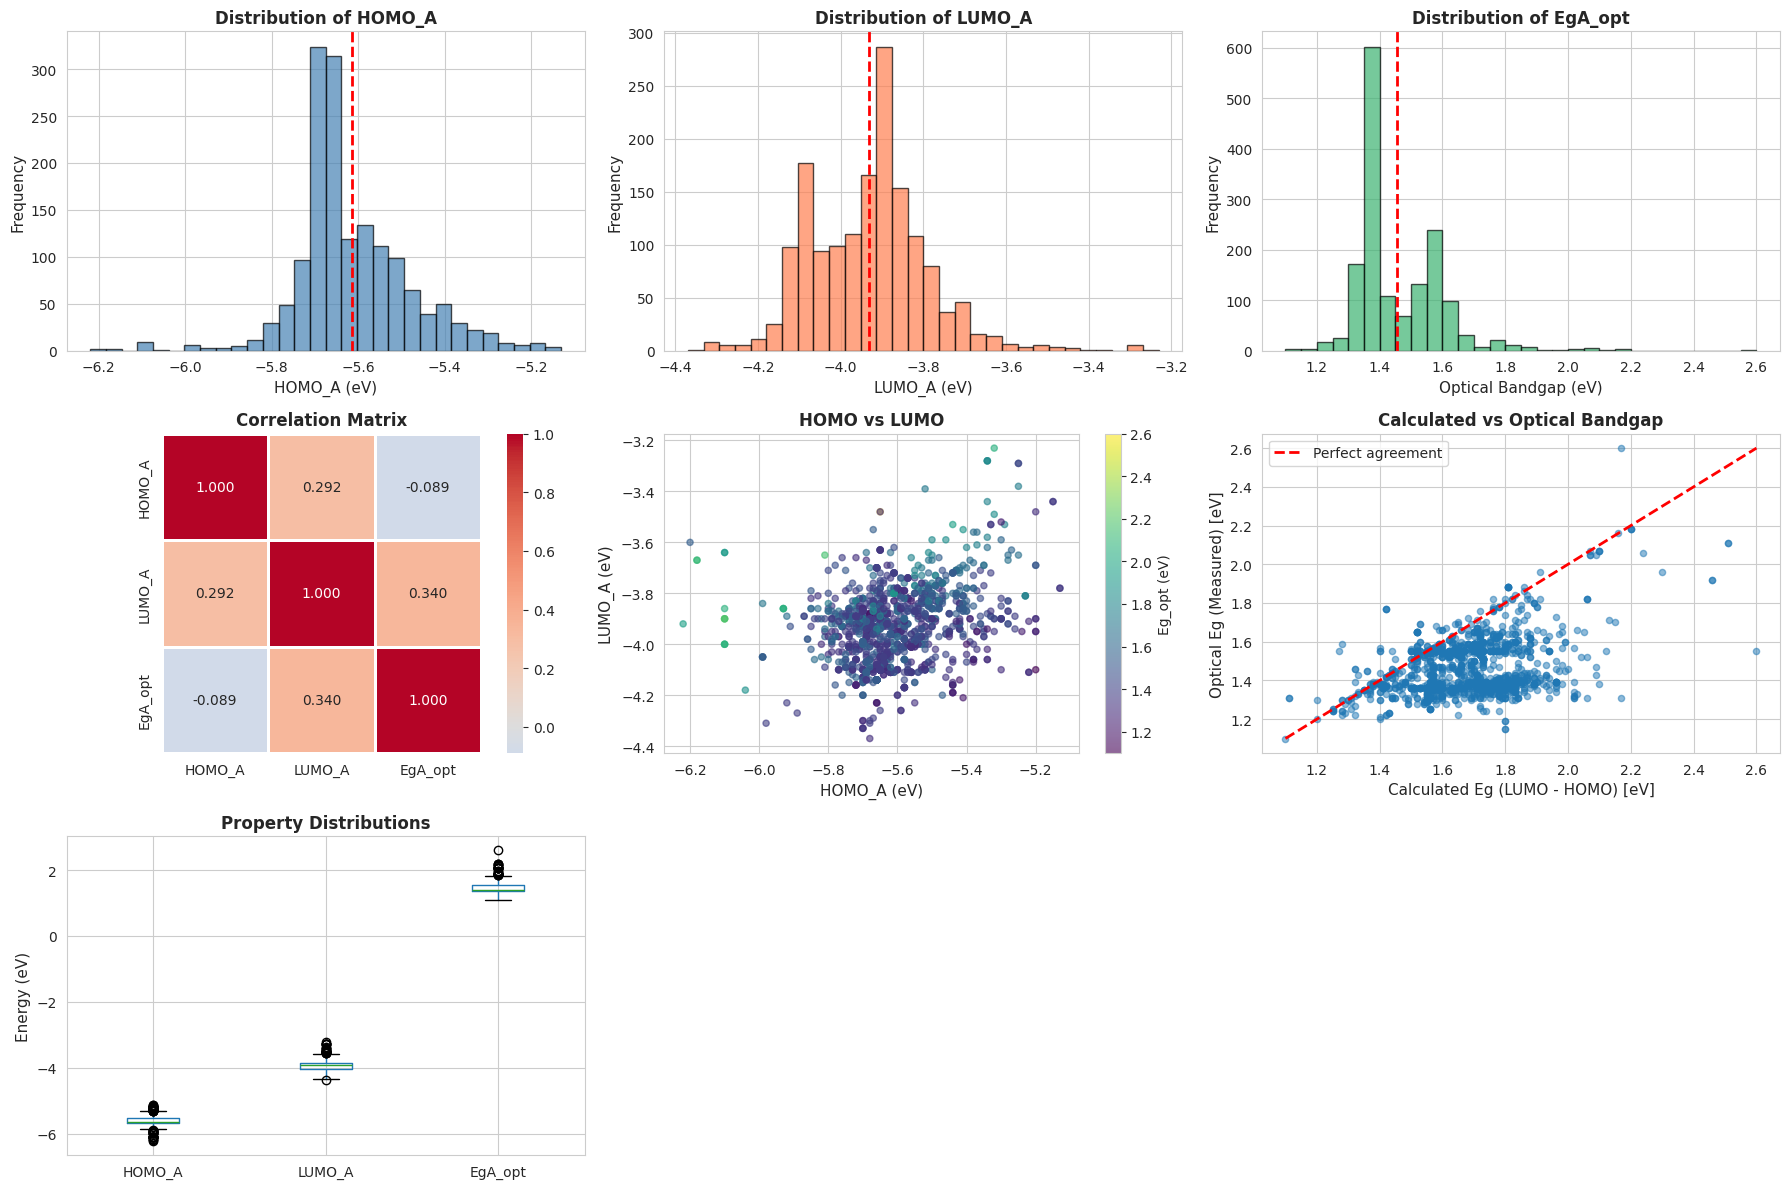

In [14]:
# Create EDA visualizations
print("\nCreating EDA visualizations...")

fig = plt.figure(figsize=(18, 12))

# 1. Distribution of HOMO
ax1 = plt.subplot(3, 3, 1)
df['HOMO_A'].hist(bins=30, color='steelblue', edgecolor='black', alpha=0.7, ax=ax1)
ax1.set_xlabel('HOMO_A (eV)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of HOMO_A', fontsize=12, fontweight='bold')
ax1.axvline(df['HOMO_A'].mean(), color='red', linestyle='--', linewidth=2)

# 2. Distribution of LUMO
ax2 = plt.subplot(3, 3, 2)
df['LUMO_A'].hist(bins=30, color='coral', edgecolor='black', alpha=0.7, ax=ax2)
ax2.set_xlabel('LUMO_A (eV)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of LUMO_A', fontsize=12, fontweight='bold')
ax2.axvline(df['LUMO_A'].mean(), color='red', linestyle='--', linewidth=2)

# 3. Distribution of Bandgap
ax3 = plt.subplot(3, 3, 3)
df['EgA_opt'].hist(bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7, ax=ax3)
ax3.set_xlabel('Optical Bandgap (eV)', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Distribution of EgA_opt', fontsize=12, fontweight='bold')
ax3.axvline(df['EgA_opt'].mean(), color='red', linestyle='--', linewidth=2)

# 4. Correlation matrix
ax4 = plt.subplot(3, 3, 4)
corr_data = df[['HOMO_A', 'LUMO_A', 'EgA_opt']].corr()
sns.heatmap(corr_data, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, ax=ax4)
ax4.set_title('Correlation Matrix', fontsize=12, fontweight='bold')

# 5. HOMO vs LUMO
ax5 = plt.subplot(3, 3, 5)
scatter = ax5.scatter(df['HOMO_A'], df['LUMO_A'], c=df['EgA_opt'],
                     cmap='viridis', alpha=0.6, s=20)
ax5.set_xlabel('HOMO_A (eV)', fontsize=11)
ax5.set_ylabel('LUMO_A (eV)', fontsize=11)
ax5.set_title('HOMO vs LUMO', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax5, label='Eg_opt (eV)')

# 6. Calculated vs Optical bandgap
ax6 = plt.subplot(3, 3, 6)
df['Calc_Eg'] = df['LUMO_A'] - df['HOMO_A']
ax6.scatter(df['Calc_Eg'], df['EgA_opt'], alpha=0.5, s=20)
ax6.plot([df['Calc_Eg'].min(), df['Calc_Eg'].max()],
         [df['Calc_Eg'].min(), df['Calc_Eg'].max()],
         'r--', linewidth=2, label='Perfect agreement')
ax6.set_xlabel('Calculated Eg (LUMO - HOMO) [eV]', fontsize=11)
ax6.set_ylabel('Optical Eg (Measured) [eV]', fontsize=11)
ax6.set_title('Calculated vs Optical Bandgap', fontsize=12, fontweight='bold')
ax6.legend()

# 7-9: Box plots
ax7 = plt.subplot(3, 3, 7)
df[['HOMO_A', 'LUMO_A', 'EgA_opt']].boxplot(ax=ax7)
ax7.set_ylabel('Energy (eV)', fontsize=11)
ax7.set_title('Property Distributions', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('EDA_visualizations.png', dpi=300, bbox_inches='tight')
print("✓ Saved: EDA_visualizations.png")
plt.show()

In [15]:
# Download visualization files
from google.colab import files
files.download('model_performance.png')
files.download('EDA_visualizations.png')

print("\n✓ STEP 4 COMPLETE - Visualizations created")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ STEP 4 COMPLETE - Visualizations created
